In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import statsmodels.api as sm
import tensorflow as tf
import torch
import pathlib

2026-03-09 16:50:48.117829: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [26]:
base_dir = pathlib.Path("data/classification-of-pet-facial-expression")
train_dir = base_dir / "train" / "train"
test_dir  = base_dir / "test" / "test"

train1_paths = sorted(train_dir.glob("*/*.jpg"))   # Angry/Happy/Sad
test1_paths  = sorted(test_dir.glob("*.jpg"))      # unlabeled test images


print("train1:", len(train1_paths), "test:", len(test1_paths))

train1: 450 test: 300


In [ ]:
from sklearn.model_selection import train_test_split
from collections import Counter

# all labeled image paths
all_paths = train1_paths

# class labels as strings first
all_labels = [p.parent.name for p in all_paths]

# stratified random split
train_paths, test_paths = train_test_split(
    all_paths,
    test_size=0.2,
    random_state=42,
    stratify=all_labels,
    shuffle=True
)
def show_class_counts(paths, name="dataset"):
    labels = [p.parent.name for p in paths]
    counts = Counter(labels)
    print(f"{name} size: {len(paths)}")
    print(counts)
    print()
show_class_counts(train_paths, "train")
show_class_counts(test_paths, "test")

# train test split of 80/20
# here on train paths is labeled train, and test paths is labeled test

train size: 360
Counter({'Happy': 120, 'Sad': 120, 'Angry': 120})

test size: 90
Counter({'Sad': 30, 'Angry': 30, 'Happy': 30})



In [30]:
classes = sorted(set((p.parent.name for p in train_paths)))
ctoi = {c: i for i,c in enumerate(classes)}
itoc = {i: c for c,i in ctoi.items()}
print("classes:", classes)

classes: ['Angry', 'Happy', 'Sad']


In [31]:
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path

from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.feature import hog
import matplotlib.pyplot as plt

In [53]:
# train and val splits for the models. Not touching test till the end.

train_subpaths, val_subpaths = train_test_split(
    train_paths,
    test_size=0.2,
    random_state=42,
    stratify=[p.parent.name for p in train_paths]
)

In [ ]:
# first feature - HOG (Histogram of GD), reduced size to 96,96 and used default otherwise
def extract_hog_features(
    image_path,
    target_size=(96, 96),
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2)
):
    """
    Load an image, convert to grayscale, resize, and extract HOG features.
    
    Parameters
    ----------
    image_path : str or Path
        Path to image file.
    target_size : tuple
        Resize image to this size before HOG.
    orientations : int
        Number of gradient orientation bins.
    pixels_per_cell : tuple
        Cell size for HOG.
    cells_per_block : tuple
        Block size for HOG normalization.
    
    Returns
    -------
    features : np.ndarray
        1D HOG feature vector.
    """
    # 1) Load image as RGB
    img = Image.open(image_path).convert("RGB")
    img = np.array(img)

    # 2) Convert to grayscale
    # Logic: HOG is mainly about edge directions, not color.
    # Grayscale makes it simpler and more robust.
    gray = rgb2gray(img)

    # 3) Resize
    # Logic: reduce dimensionality and noise while preserving coarse structure.
    gray_resized = resize(
        gray,
        target_size,
        anti_aliasing=True
    )

    # 4) Extract HOG
    features = hog(
        gray_resized,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm="L2-Hys",
        feature_vector=True
    )

    return features

In [ ]:
def show_hog_visualization(
    image_path,
    target_size=(96, 96),
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2)
):
    img = Image.open(image_path).convert("RGB")
    img = np.array(img)

    gray = rgb2gray(img)
    gray_resized = resize(gray, target_size, anti_aliasing=True)

    features, hog_image = hog(
        gray_resized,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm="L2-Hys",
        visualize=True,
        feature_vector=True
    )

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].imshow(gray_resized, cmap="gray")
    axes[0].set_title("Resized grayscale")
    axes[0].axis("off")

    axes[1].imshow(hog_image, cmap="gray")
    axes[1].set_title("HOG visualization")
    axes[1].axis("off")

    plt.show()

    print("HOG feature length:", len(features))

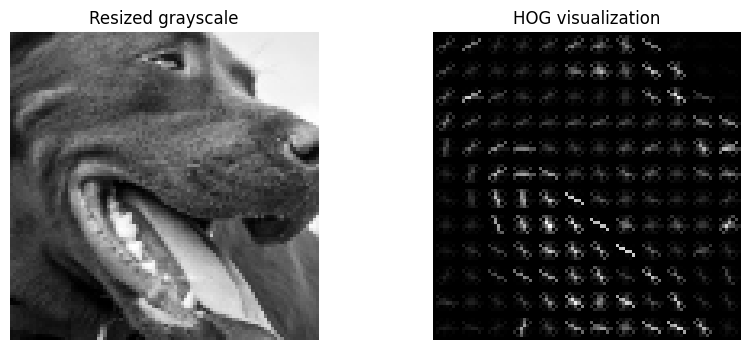

HOG feature length: 4356


In [34]:
show_hog_visualization(train_paths[0])

In [36]:
def build_hog_dataset(
    image_paths,
    class_to_index=None,
    target_size=(96, 96),
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2)
):
    X = []
    y = []

    for p in image_paths:
        feats = extract_hog_features(
            p,
            target_size=target_size,
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block
        )
        X.append(feats)

        if class_to_index is not None:
            label = p.parent.name
            y.append(class_to_index[label])

    X = np.array(X)
    y = np.array(y) if class_to_index is not None else None

    return X, y

In [55]:
X_train_hog, y_train = build_hog_dataset(train_subpaths, class_to_index=ctoi)
X_val_hog, y_val = build_hog_dataset(val_subpaths, class_to_index=ctoi)

In [56]:
# RF as clean baseline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_hog, y_train)
preds = rf.predict(X_val_hog)

print(classification_report(y_val, preds, target_names=list(ctoi.keys())))

              precision    recall  f1-score   support

       Angry       0.52      0.50      0.51        24
       Happy       0.56      0.62      0.59        24
         Sad       0.36      0.33      0.35        24

    accuracy                           0.49        72
   macro avg       0.48      0.49      0.48        72
weighted avg       0.48      0.49      0.48        72



In [40]:
import numpy as np
from PIL import Image
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.feature import local_binary_pattern

In [ ]:
# extracting second feature, Local binary patterns
def extract_lbp_features(
    image_path,
    target_size=(96, 96),
    radius=1,
    method="uniform"
):
    """
    Load an image, convert to grayscale, resize, compute LBP,
    and return a normalized histogram of LBP codes.
    """
    # 1) Load image
    img = Image.open(image_path).convert("RGB")
    img = np.array(img)

    # 2) Convert to grayscale
    gray = rgb2gray(img)

    # 3) Resize
    gray_resized = resize(gray, target_size, anti_aliasing=True)

    # 4) LBP parameters
    # P = number of sampled neighbors on the circle
    P = 8 * radius

    # 5) Compute LBP image
    lbp = local_binary_pattern(gray_resized, P=P, R=radius, method=method)

    # 6) Build histogram
    if method == "uniform":
        n_bins = P + 2
    else:
        n_bins = int(lbp.max() + 1)

    hist, _ = np.histogram(
        lbp.ravel(),
        bins=n_bins,
        range=(0, n_bins),
        density=True
    )

    return hist

In [1]:
lbp_feats = extract_lbp_features(train_paths[0])
print(lbp_feats.shape)
print(lbp_feats)

NameError: name 'extract_lbp_features' is not defined

In [43]:
def build_lbp_dataset(
    image_paths,
    class_to_index=None,
    target_size=(96, 96),
    radius=1,
    method="uniform"
):
    X = []
    y = []

    for p in image_paths:
        feats = extract_lbp_features(
            p,
            target_size=target_size,
            radius=radius,
            method=method
        )
        X.append(feats)

        if class_to_index is not None:
            y.append(class_to_index[p.parent.name])

    X = np.array(X)
    y = np.array(y) if class_to_index is not None else None

    return X, y

In [58]:
X_train_lbp, y_train_lpb = build_lbp_dataset(train_subpaths, class_to_index=ctoi)
X_val_lbp, y_val_lpb = build_lbp_dataset(val_subpaths, class_to_index=ctoi)
X_train_lbp.shape, y_train_lpb.shape, X_val_lbp.shape, y_val_lpb.shape

/Users/ishittaiyer/Desktop/sta314-project/.venv/lib/python3.12/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


((288, 10), (288,), (72, 10), (72,))

In [ ]:
# trying rf on lbp features
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_lbp, y_train_lpb)
preds = rf.predict(X_val_lbp)

print(classification_report(y_val, preds, target_names=sorted(ctoi.keys())))

              precision    recall  f1-score   support

       Angry       0.42      0.33      0.37        24
       Happy       0.55      0.67      0.60        24
         Sad       0.46      0.46      0.46        24

    accuracy                           0.49        72
   macro avg       0.48      0.49      0.48        72
weighted avg       0.48      0.49      0.48        72



In [ ]:
# trying rf on both hog and lpb
X_train_combined1 = np.hstack([X_train_hog, X_train_lbp])
X_val_combined1 = np.hstack([X_val_hog, X_val_lbp])

print(X_train_combined1.shape, X_val_combined1.shape, y_val.shape, y_train.shape)

(288, 4366) (72, 4366) (72,) (288,)


In [70]:
rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_combined1, y_train)
preds = rf.predict(X_val_combined1)

print(classification_report(y_val, preds, target_names=sorted(ctoi.keys())))

              precision    recall  f1-score   support

       Angry       0.57      0.54      0.55        24
       Happy       0.53      0.75      0.62        24
         Sad       0.53      0.33      0.41        24

    accuracy                           0.54        72
   macro avg       0.54      0.54      0.53        72
weighted avg       0.54      0.54      0.53        72



In [ ]:
# feature 3 :regional lbp for regional features

def extract_regional_lbp_features(
    image_path,
    target_size=(96, 96),
    grid_size=(4, 4),
    radius=1,
    method="uniform"
):
    """
    Extract regional LBP features by:
    1. loading image
    2. converting to grayscale
    3. resizing
    4. splitting into a grid
    5. computing an LBP histogram in each cell
    6. concatenating all histograms
    """
    # Load image
    img = Image.open(image_path).convert("RGB")
    img = np.array(img)

    # Grayscale
    gray = rgb2gray(img)

    # Resize
    gray_resized = resize(gray, target_size, anti_aliasing=True)

    # LBP setup
    P = 8 * radius
    lbp = local_binary_pattern(gray_resized, P=P, R=radius, method=method)

    if method == "uniform":
        n_bins = P + 2
    else:
        n_bins = int(lbp.max() + 1)

    # Grid setup
    n_rows, n_cols = grid_size
    h, w = lbp.shape
    cell_h = h // n_rows
    cell_w = w // n_cols

    features = []

    for i in range(n_rows):
        for j in range(n_cols):
            cell = lbp[
                i * cell_h:(i + 1) * cell_h,
                j * cell_w:(j + 1) * cell_w
            ]

            hist, _ = np.histogram(
                cell.ravel(),
                bins=n_bins,
                range=(0, n_bins),
                density=True
            )

            features.extend(hist)

    return np.array(features, dtype=np.float32)

In [66]:
def build_regional_lbp_dataset(
    image_paths,
    class_to_index=None,
    target_size=(96, 96),
    grid_size=(4, 4),
    radius=1,
    method="uniform"
):
    X = []
    y = []

    for p in image_paths:
        feats = extract_regional_lbp_features(
            p,
            target_size=target_size,
            grid_size=grid_size,
            radius=radius,
            method=method
        )
        X.append(feats)

        if class_to_index is not None:
            y.append(class_to_index[p.parent.name])

    X = np.array(X)
    y = np.array(y) if class_to_index is not None else None

    return X, y

In [67]:
X_train_rlbp, y_train = build_regional_lbp_dataset(train_subpaths, class_to_index=ctoi)
X_val_rlbp, y_val = build_regional_lbp_dataset(val_subpaths, class_to_index=ctoi)

print(X_train_rlbp.shape, y_train.shape)
print(X_val_rlbp.shape, y_val.shape)

/Users/ishittaiyer/Desktop/sta314-project/.venv/lib/python3.12/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


(288, 160) (288,)
(72, 160) (72,)


In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_rlbp, y_train)
preds = rf.predict(X_val_rlbp)

print(classification_report(y_val, preds, target_names=sorted(ctoi.keys())))

              precision    recall  f1-score   support

       Angry       0.48      0.46      0.47        24
       Happy       0.47      0.79      0.59        24
         Sad       0.22      0.08      0.12        24

    accuracy                           0.44        72
   macro avg       0.39      0.44      0.39        72
weighted avg       0.39      0.44      0.39        72



In [ ]:
# using all 3 features
X_train_combined2 = np.hstack([X_train_hog, X_train_rlbp, X_train_lbp])
X_val_combined2 = np.hstack([X_val_hog, X_val_rlbp, X_val_lbp])
X_train_combined2.shape, X_val_combined2.shape

((288, 4526), (72, 4526))

In [74]:
rf.fit(X_train_combined2, y_train)
preds = rf.predict(X_val_combined2)
print(classification_report(y_val, preds, target_names=sorted(ctoi.keys())))

              precision    recall  f1-score   support

       Angry       0.61      0.46      0.52        24
       Happy       0.58      0.79      0.67        24
         Sad       0.57      0.50      0.53        24

    accuracy                           0.58        72
   macro avg       0.59      0.58      0.57        72
weighted avg       0.59      0.58      0.57        72



In [75]:
X_train_combined3 = np.hstack([X_train_hog, X_train_rlbp])
X_val_combined3 = np.hstack([X_val_hog, X_val_rlbp])
X_train_combined3.shape, X_val_combined3.shape

((288, 4516), (72, 4516))

In [ ]:
# rf on just hog + rlpb
rf.fit(X_train_combined3, y_train)
preds = rf.predict(X_val_combined3)
print(classification_report(y_val, preds, target_names=sorted(ctoi.keys())))

              precision    recall  f1-score   support

       Angry       0.52      0.50      0.51        24
       Happy       0.62      0.75      0.68        24
         Sad       0.60      0.50      0.55        24

    accuracy                           0.58        72
   macro avg       0.58      0.58      0.58        72
weighted avg       0.58      0.58      0.58        72



In [78]:
import numpy as np
from PIL import Image
from skimage.color import rgb2gray
from skimage.transform import resize
from skimage.feature import canny
from skimage.filters import sobel

In [ ]:
# 4th feature, regional stats
def extract_regional_stats_features(
    image_path,
    target_size=(96, 96),
    grid_size=(4, 4)
):
    """
    Extract regional summary features from an image:
    - mean intensity
    - std intensity
    - mean gradient magnitude
    - std gradient magnitude
    - edge density

    Returns one concatenated feature vector.
    """
    # Load and preprocess
    img = Image.open(image_path).convert("RGB")
    img = np.array(img)

    gray = rgb2gray(img)
    gray_resized = resize(gray, target_size, anti_aliasing=True)

    # Gradient magnitude image
    grad = sobel(gray_resized)

    # Binary edge map
    edges = canny(gray_resized)

    n_rows, n_cols = grid_size
    h, w = gray_resized.shape
    cell_h = h // n_rows
    cell_w = w // n_cols

    features = []

    for i in range(n_rows):
        for j in range(n_cols):
            r0, r1 = i * cell_h, (i + 1) * cell_h
            c0, c1 = j * cell_w, (j + 1) * cell_w

            gray_cell = gray_resized[r0:r1, c0:c1]
            grad_cell = grad[r0:r1, c0:c1]
            edge_cell = edges[r0:r1, c0:c1]

            # Intensity stats
            features.append(gray_cell.mean())
            features.append(gray_cell.std())

            # Gradient stats
            features.append(grad_cell.mean())
            features.append(grad_cell.std())

            # Edge density = fraction of edge pixels
            features.append(edge_cell.mean())

    return np.array(features, dtype=np.float32)

In [80]:
def build_regional_stats_dataset(
    image_paths,
    class_to_index=None,
    target_size=(96, 96),
    grid_size=(4, 4)
):
    X = []
    y = []

    for p in image_paths:
        feats = extract_regional_stats_features(
            p,
            target_size=target_size,
            grid_size=grid_size
        )
        X.append(feats)

        if class_to_index is not None:
            y.append(class_to_index[p.parent.name])

    X = np.array(X)
    y = np.array(y) if class_to_index is not None else None

    return X, y

In [81]:
X_train_stats, y_train = build_regional_stats_dataset(train_subpaths, class_to_index=ctoi)
X_val_stats, y_val = build_regional_stats_dataset(val_subpaths, class_to_index=ctoi)

print(X_train_stats.shape, y_train.shape)
print(X_val_stats.shape, y_val.shape)

(288, 80) (288,)
(72, 80) (72,)


In [ ]:
# using rlpb + stats + hog
X_train_combined4 = np.hstack([X_train_combined3, X_train_stats])
X_val_combined4 = np.hstack([X_val_combined3, X_val_stats])
X_train_combined4.shape, X_val_combined4.shape

((288, 4596), (72, 4596))

In [83]:
rf.fit(X_train_combined4, y_train)
preds = rf.predict(X_val_combined4)
print(classification_report(y_val, preds, target_names=sorted(ctoi.keys())))

              precision    recall  f1-score   support

       Angry       0.65      0.62      0.64        24
       Happy       0.60      0.75      0.67        24
         Sad       0.47      0.38      0.42        24

    accuracy                           0.58        72
   macro avg       0.58      0.58      0.57        72
weighted avg       0.58      0.58      0.57        72



In [ ]:
# tuned rf

rf1 = RandomForestClassifier(
    n_estimators=500,
        max_features="sqrt",      # limits correlation between trees
        min_samples_leaf=3,       # prevents overfitting on small data
        max_depth=None,           # min_samples_leaf controls it
        class_weight="balanced",  
    )

In [ ]:
rf1.fit(X_train_combined4, y_train)
preds1 = rf1.predict(X_val_combined4)
print(classification_report(y_val, preds1, target_names=sorted(ctoi.keys())))
# 0.62 recall and precision, seems okay as a baseline to work up from

              precision    recall  f1-score   support

       Angry       0.61      0.58      0.60        24
       Happy       0.70      0.79      0.75        24
         Sad       0.55      0.50      0.52        24

    accuracy                           0.62        72
   macro avg       0.62      0.62      0.62        72
weighted avg       0.62      0.62      0.62        72



In [ ]:
# trying pca because too many dim
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95, whiten=True)
X_train_pca = pca.fit_transform(X_train_combined4)
X_val_pca = pca.transform(X_val_combined4)

In [88]:
X_train_pca.shape , X_val_pca.shape

((288, 225), (72, 225))

In [89]:
assert X_train_combined4.shape[1] == X_val_combined4.shape[1], "Feature mismatch!"
print(f"Features before PCA: {X_train_combined4.shape[1]}")
print(f"Components kept: {pca.n_components_}")
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.3f}")

Features before PCA: 4596
Components kept: 225
Variance explained: 0.951


In [90]:
rf1.fit(X_train_pca, y_train)
preds2 = rf1.predict(X_val_pca)
print(classification_report(y_val, preds2, target_names=sorted(ctoi.keys())))

              precision    recall  f1-score   support

       Angry       0.40      0.58      0.47        24
       Happy       0.44      0.29      0.35        24
         Sad       0.43      0.38      0.40        24

    accuracy                           0.42        72
   macro avg       0.42      0.42      0.41        72
weighted avg       0.42      0.42      0.41        72



In [91]:
rf1.fit(X_train_combined4, y_train)

importances = rf1.feature_importances_
threshold = np.percentile(importances, 25)  # drop bottom 25% of features
mask = importances >= threshold

X_train_filtered = X_train_combined4[:, mask]
X_val_filtered = X_val_combined4[:, mask]

In [92]:
rf2 = RandomForestClassifier(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=3,
    max_depth=None,
    class_weight="balanced",
    random_state=42
)

rf2.fit(X_train_filtered, y_train)
preds3 = rf2.predict(X_val_filtered)
print(classification_report(y_val, preds3, target_names=sorted(ctoi.keys())))

              precision    recall  f1-score   support

       Angry       0.61      0.58      0.60        24
       Happy       0.62      0.75      0.68        24
         Sad       0.55      0.46      0.50        24

    accuracy                           0.60        72
   macro avg       0.59      0.60      0.59        72
weighted avg       0.59      0.60      0.59        72



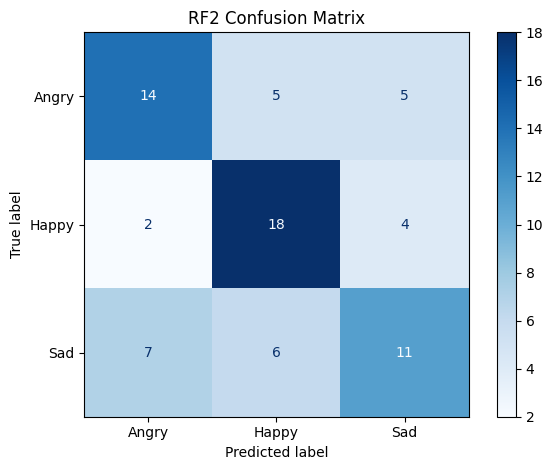

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf2, X_val_filtered, y_val,
    display_labels=sorted(ctoi.keys()),
    cmap="Blues"
)
plt.title("RF2 Confusion Matrix")
plt.tight_layout()
plt.show()
# clearly sad is horrible. happy is working well, and angry is medium. the model is confused for sad.